<a id='top'></a>



<a id='top'></a>


# CSCI3022 S23


# Homework 10: Bootstrapping and Intro to SLR
## Due Monday, April 24th at 11:59pm to Gradescope
***

**Name**: Dominic Galgano

***

***
### Collaboration Policy

While completing the assignment you are not allowed to consult any source other than the course textbooks/online reference links provided on Canvas, your own class notes, and/or the posted lecture slides/in-class Jupyter notebooks.   You may discuss questions you have with your classmates or on Piazza or in office hours, but all work you submit must be your own, which means when writing up your solutions or code, you MUST do it entirely by yourself. 

You should be able to easily reproduce from scratch and explain a solution that was your own when asked in office hours by a TA/Instructor or on a quiz/exam without referencing your notes/book/HW.   


**Do not search/ask for a solution online**: You may not actively search for a solution to the problems below from the internet. This includes posting to or using sources like ChatGPT, StackOverflow, StackExchange, Reddit, Chegg, CourseHero, etc.  

**We are here to help!  Visit HW Hours and/or post questions on Piazza!**


Copying/consulting from the solution of another classmate or an online solution (or providing a classmate your solution) constitutes a **violation of the course's collaboration policy and the honor code and will result in an F in the course and a trip to the honor council**.   






### Instructions for Submitting in Correct Format 

You must submit a PDF of this Juptyer notebook to Gradescope by the deadline listed above.  Submissions that are not a PDF or that are not submitted to Gradescope will not be counted for credit.  

$\color{red}{\text{Before submitting your PDF, make sure that your LaTeX has rendered correctly in your PDF.}}$
$\color{red}{\text{Any of your solutions with incorrectly rendered or incompletely rendered LaTeX will be given 0 points.}}$ 

- There are several ways to quickly make a .pdf out of this notebook for Gradescope submission.  
 
 - If you are running Juptyer locally on your computer: 
 
     - Option1 : Select Kernel->Restart & Run All.  Then select File ->  Print Preview, and then Right-Click -> Print using your default browser and "Print to PDF"
 
     - Option 2: Select Kernel->Restart & Run All.   Then select File -> Download as PDF via LaTeX.  This will require your system path find a working install of a TeX compiler
 
 - If you are running using CSEL: 
 
     - Option1 :  Go to File ->Save & Export Notebook As-> HTML.  Then open the HTML, and then Right-Click -> Print and select "Print to PDF".  
     - Option2 :  Go to File ->Download. Then use this converter https://htmtopdf.herokuapp.com/ipynbviewer/ to convert ipynb to pdf.
 
### Notes
- For full points you must correctly match your questions to the respective Gradescope problem, and include clear comments in your code.   Please note that any LaTeX that is not correctly rendered in your submitted PDF will result in a 0 on the entire problem(s) that involves the unrendered LaTeX. 
- You **must show all work and justify ALL answers to receive credit**. Sparse or nonexistent work will receive sparse or nonexistent credit. 
- Any relevant data sets are available on Canvas. 
- LaTeX Tips:  Here is a [reference guide] (https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference).  **All** of your written commentary, justifications and mathematical work should be in Markdown.  I also recommend the [wikibook](https://en.wikibooks.org/wiki/LaTeX) for LaTex.
- Because you can technically evaluate notebook cells is a non-linear order, it's a good idea to do **Kernel $\rightarrow$ Restart & Run All** as a check before submitting your solutions.  
- It is **bad form** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code. 

- There is *not a prescribed API* for these problems.  You may answer coding questions with whatever syntax or object typing you deem fit.  Your evaluation will primarily live in the clarity of how well you present your final results, so don't skip over any interpretations!  Your code should still be commented and readable to ensure you followed the given course algorithm.




We'll need Numpy, Matplotlib, Pandas, and scipy.stats for this notebook, so let's load them. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import scipy.stats as stats
import statsmodels.api as sm
from patsy import dmatrices
%matplotlib inline

#I added the math import
import math as math


---
**Shortcuts:**  [Problem 1](#p1) | [Problem 2](#p2) |[Problem 3](#p3) 
---


<br>

---
<a/ id='p1'></a>

### [4 points] Problem 1  - Scientists vs. P-Values 
***

Read the following article from **FiveThirtyEight**: [Statisticians Found One Thing They Can Agree On: It's Time to Stop Misusing P-Values](http://fivethirtyeight.com/features/statisticians-found-one-thing-they-can-agree-on-its-time-to-stop-misusing-p-values/). Then answer the following questions:  

Based on the article:

a).  In what ways are scientists misusing p-values? 

One way scientists were misusing p-values is they were claiming when the p-value is sufficiently large enough they accept the null hypothesis as true, which cannot be done using the p-value since they can only not reject the null hypothesis.

Another way scientists misused p-values is how they cherry pick data to get a p-value that allows them to not reject the null, also known as p-hacking, which would lead to results that could not be reproduced. However, it's likely this occurred because some studies are not published unless they have an acceptable p-value


b).  What suggestions are being made to use them properly?

According to the article, it was suggested that other methodologies be used to determine, such as confidence intervals, but it was believed this would only shift around the problem. Andrew Gelman, University of Columbia statistican said we must "...move toward a greater acceptance of uncertainty and embracing of variation", which I think he is saying to stop p-hacking data and accepting null hypotheses based on p-values.

<br>

---
<a/ id='p2'></a>
[Back to top](#top)
## (22 pts) Problem 2  (Confidence Intervals & Bootstrapping)

Consider the `hubble.csv` sample data set we used in nb09. (A description of the variables can be obtained from page 73 of https://cran.r-project.org/web/packages/gamair/gamair.pdf.) 

We're interested in using this sample data to calculate the mean distance from a galaxy to Earth in Mega parsecs (column `x` of the data).

Load the data into a dataframe:



In [2]:
dfHubble = pd.read_csv("hubble.csv")


**Part A**:

When creating a $t$-confidence interval when we have less than 30 data points, the theoretical assumptions require that the population distribution is approximately normally distributed.  Let's check this assumption visually:

**Part A1: (2 pts)** Make a **density** histogram of the '$x$' data and overlay the theoretical density of the normal with mean $\bar{x}$ and sample variance $s^2$.  
 

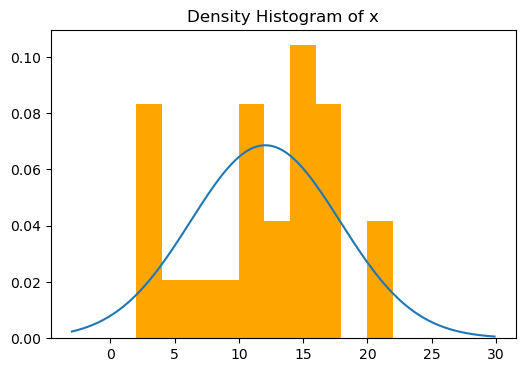

In [3]:
fig, ax= plt.subplots(figsize=(6,4))

ax.hist(dfHubble['x'], density = True, color = "orange")
ax.set_title('Density Histogram of x')

mean_x = dfHubble['x'].mean()
sd = dfHubble['x'].std()

x_axis = np.arange(-3, 30, 0.1)
    
ax.plot(x_axis, stats.norm.pdf(x_axis, mean_x, sd))
##plt.show()


**Part A2: (1 pt)** Make a QQ-plot of the '$x$' data compared with the quantiles of a normal distribution. 
  

Figure(640x480)


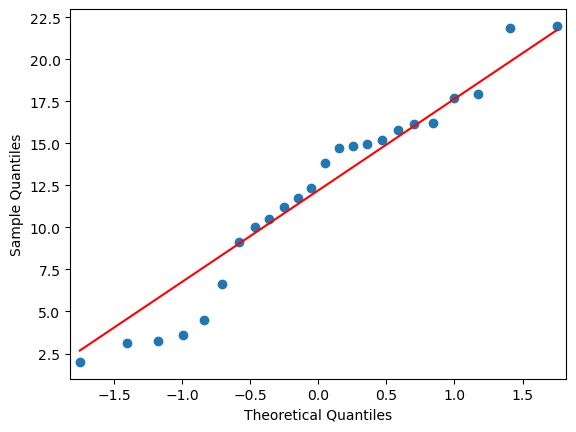

In [4]:
print(sm.qqplot(dfHubble['x'],line='q'))

**Part A3:(1 pt)**  Based on your plots above, does this data appear approximately normally distributed or not?  Explain.
  

Yes, because although the data seems to stray from the line near the bottom, for most of the line it is close to the line meaning it is very close to following the normal distribution

**Part B**:

Things may not look perfectly normal in part A.  Fortunately, as long as the distribution is not extremely skewed, the theoretical method is pretty robust.  To see this, let's create confidence intervals using the theory that requires normality anyway, to see how it does:   

For Part B only, assume each observation is independent and identically distributed as a normal random variable.

**Part B1 (2 pts)** Create a 95% confidence interval for the mean of a galaxy's distance from Earth in Mega parsecs from scratch using the definition of a t-confidence interval shown below (i.e. use the data to calculate each of the variables shown below, and do NOT use a built-in confidence interval method):

$$\bar{x} \pm t_{\alpha/2,n-1}\hspace{1mm}\frac{s}{\sqrt{n}} $$


In [5]:
#Establish variables used in formula
sm_x = dfHubble['x'].mean()
sd_x = dfHubble['x'].std()
n = len(dfHubble['x'])
t = stats.t.ppf(0.975, df = n - 2)

#Calculate upper and lower bounds
upper = sm_x + (t * (sd_x / math.sqrt(n)))
lower = sm_x - (t * (sd_x / math.sqrt(n))) 
print("Confidence Interval: [", lower, ",", upper, "]")

Confidence Interval: [ 9.59308226463462 , 14.516084402032046 ]


**Part B2 (1 pt)** Check your answer to B1 using a built-in function to calculate t-confidence intervals.  

In [6]:
stats.t.interval(alpha=0.95, df=n-1, loc=sm_x, scale=stats.sem(dfHubble['x']))

/tmp/ipykernel_258/2060279886.py:1: DeprecationWarning: Use of keyword argument `alpha` for method `interval` is deprecated. Use first positional argument or keyword argument `confidence` instead.
  stats.t.interval(alpha=0.95, df=n-1, loc=sm_x, scale=stats.sem(dfHubble['x']))


(9.599272544248016, 14.50989412241865)

**Part B3** Suppose you were only given the output of this confidence interval.  Determine whether or not you can answer the questions below, and if so, answer them.  If not, explain what additional information you'd need:

 - **Part B3i (1 pt)** Using only the confidence interval you found in part B2, can you find the sample mean $\bar{x}$ for the galaxy data?  If so, find it and then check your answer by actually computing the sample mean (you can use built-in functions).
 

Yes you can estimate the sample mean using the confidence interval using:

$\bar{x} = Upper - \frac{Upper - Lower}{2}$

Therefore, $\bar{x} = 14.510 - \frac{14.510 - 9.599}{2}$

$\bar{x} = \boxed{12.0545}$

 - **Part B3ii (2 pts)** Suppose want to test the hypothesis that the population mean of a galaxy's distance from Earth is $H_0: \mu_x=16$ (Mega parsecs) vs $H_A: \mu_x\neq 16$ (Mega parsecs), at the $95\%$ confidence level.   Using only the confidence interval from part B2 can you make a conclusion about your test?  What does your test conclude?
 

Yes, you can conclude to accept $H_A: \mu_x\neq 16$ because the confidence interval [9.599, 14.510] does not contain the $\mu_x = 16$, therefore it is extremely unlikely the null hypothesis would be corrected and we can reject it.


 - **Part B3iii (1 pt)** Check your answer to part (B3ii) by conducting a hypothesis test using the built-in function `scipy.stats.ttest_1samp` (https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_1samp.html) 

 - What is the p-value?  What is the conclusion of the test using this p-value?
 

In [7]:
stats.ttest_1samp(dfHubble['x'], 16)

Ttest_1sampResult(statistic=-3.324107176189548, pvalue=0.0029535863887783795)

The $p-value = 0.00295$ which is less than the accepted signficance level $\alpha = 0.05$ therefore we can reject the null hypothesis

**Part C**:

For part C only, assume each observation is independent and identically distributed but is **not** normally distributed. In that case we can use  bootstrapping to create a 95% confidence interval for the mean of a galaxy's distance from Earth in Mega parsecs.  

**Part C1 (2 pts)** Write code for a function to take in sample data and draw $10000$ bootstrapped resamples (with replacement) from the data.   This function should: 

 - Plot a histogram of the bootstrapped sample means

 - Compute a bootstrapped confidence interval for the mean at the 95% confidence level

 - Plot the confidence interval for the mean on the histogram (see nb10 for an example)
  


[9.754885416666665, 14.288791666666665]

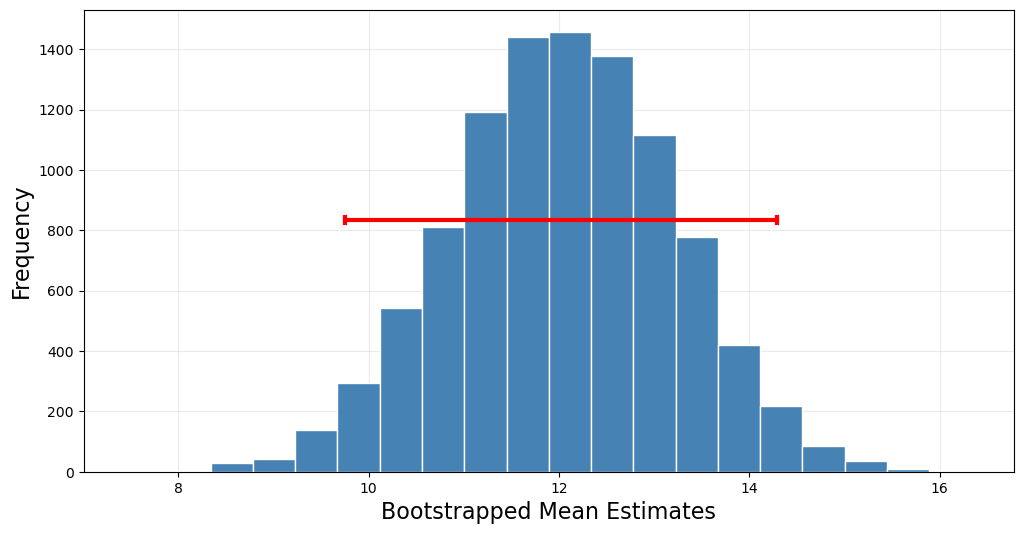

In [8]:
def bootstrapped_mean(sample, num_boots=10000):
    
    list_of_means = []
    
    for i in range(0,num_boots):
        resample = np.random.choice(sample, size = len(sample), replace = True)
        mean_resample = np.mean(resample)
        list_of_means.append(mean_resample)
    L = np.percentile(list_of_means,2.5)
    U = np.percentile(list_of_means,97.5)
    
    CI = [L, U]

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    pd.Series(list_of_means).hist(ax=ax, color="steelblue", edgecolor="white", bins=20, density=False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlabel("Bootstrapped Mean Estimates", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    
    ax.plot([CI[0], CI[1]], [num_boots/12, num_boots/12], color="red", lw=3)
    ax.plot([CI[0], CI[0]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    ax.plot([CI[1], CI[1]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    return CI


bootstrapped_mean(dfHubble['x'])  

***Part C2 (1 pt)***  Compare your bootstrapped CI to the theoretical CI you computed in Part B.  Are they similar or different? 

My bootstrapped lower limit of $9.749$ is slightly greater than by computed lower limit of $9.599$ by about $0.15$. 

My bootstrapped upper limit of $14.301$ is slightly less than my computed upper limit of $14.510$ by about $0.209$.

Overall the bootstrapped confidence interval is pretty close to the computed confidence interval, with the bootstrapped interval being slightly smaller by about $0.359$

**Part D** 
Bootstrapping is useful for calculating CIs for many other population parameters (not just means).  
For each of the parameters below:
 - use bootstrapping to create the indicated confidence interval AND 
 - overlay this confidence interval on a histogram of the bootstrapped results (similar to Part C).

Your final answer to this part should include 4 different histograms and CIs (one for each parameter).  


**Part D1 (2 pts)** A $90\%$ CI for the **standard deviation** of a galaxy's distance from Earth in Mega parsecs.

[4.470286261753589, 6.543407479564247]

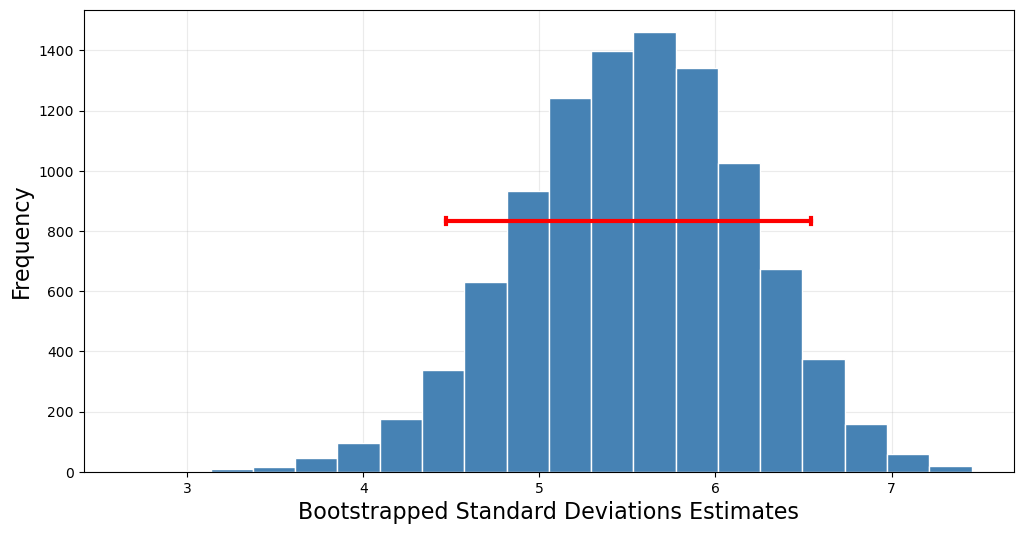

In [9]:
def bootstrapped_std(sample, num_boots=10000):
    
    list_of_stds = []
    
    for i in range(0,num_boots):
        resample = np.random.choice(sample, size = len(sample), replace = True)
        std_resample = np.std(resample)
        list_of_stds.append(std_resample)
    L = np.percentile(list_of_stds, 5)
    U = np.percentile(list_of_stds,95)
    
    CI = [L, U]

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    pd.Series(list_of_stds).hist(ax=ax, color="steelblue", edgecolor="white", bins=20, density=False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlabel("Bootstrapped Standard Deviations Estimates", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    
    ax.plot([CI[0], CI[1]], [num_boots/12, num_boots/12], color="red", lw=3)
    ax.plot([CI[0], CI[0]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    ax.plot([CI[1], CI[1]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    return CI


bootstrapped_std(dfHubble['x'])  

**Part D2 (2 pts)** An $85\%$ CI for the **lower quartile** of a galaxy's distance from Earth in Mega parsecs.



[3.63, 11.22]

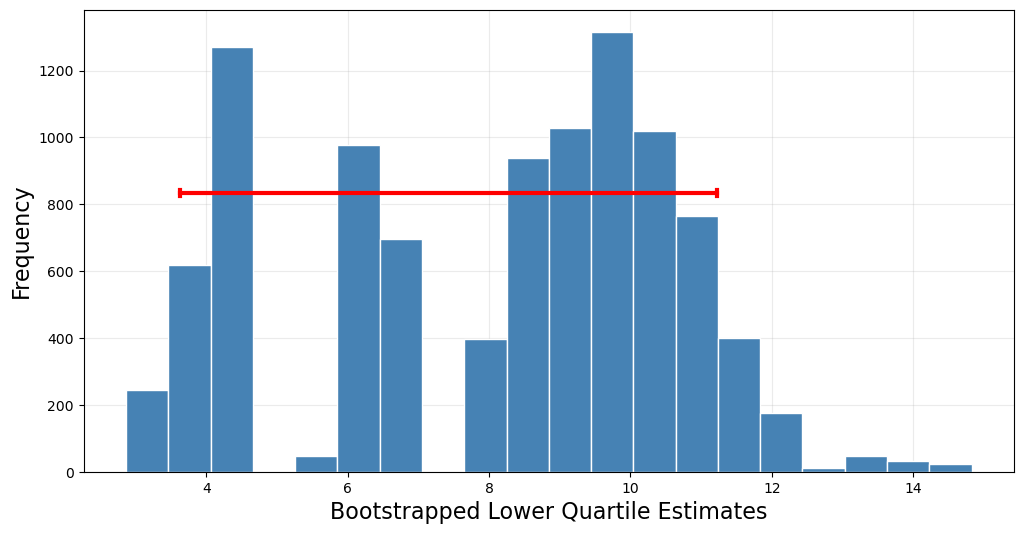

In [10]:
def bootstrapped_lq(sample, num_boots=10000):
    
    list_of_lqs = []
    
    for i in range(0,num_boots):
        resample = np.random.choice(sample, size = len(sample), replace = True)
        lq_resample = np.quantile(resample, 0.25)
        list_of_lqs.append(lq_resample)
    L = np.percentile(list_of_lqs, 7.5)
    U = np.percentile(list_of_lqs, 92.5)
    
    CI = [L, U]

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    pd.Series(list_of_lqs).hist(ax=ax, color="steelblue", edgecolor="white", bins=20, density=False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlabel("Bootstrapped Lower Quartile Estimates", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    
    ax.plot([CI[0], CI[1]], [num_boots/12, num_boots/12], color="red", lw=3)
    ax.plot([CI[0], CI[0]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    ax.plot([CI[1], CI[1]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    return CI


bootstrapped_lq(dfHubble['x'])  

**Part D3 (2 pts)**  A $94\%$ CI for the **upper quartile** of a galaxy's distance from Earth in Mega parsecs.



[14.4044, 17.7625]

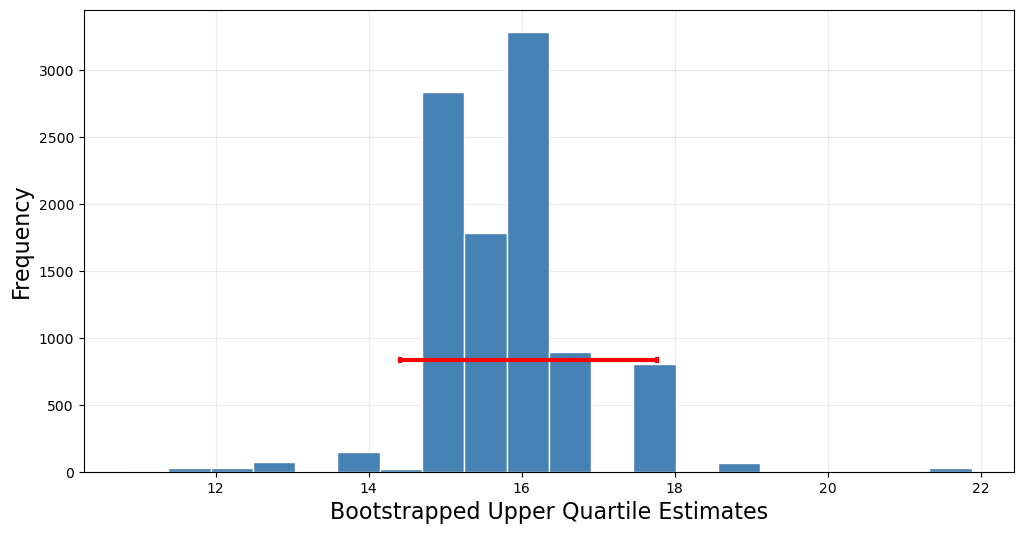

In [11]:
def bootstrapped_up(sample, num_boots=10000):
    
    list_of_uqs = []
    
    for i in range(0,num_boots):
        resample = np.random.choice(sample, size = len(sample), replace = True)
        uq_resample = np.quantile(resample, 0.75)
        list_of_uqs.append(uq_resample)
    L = np.percentile(list_of_uqs, 3)
    U = np.percentile(list_of_uqs, 97)
    
    CI = [L, U]

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    pd.Series(list_of_uqs).hist(ax=ax, color="steelblue", edgecolor="white", bins=20, density=False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlabel("Bootstrapped Upper Quartile Estimates", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    
    ax.plot([CI[0], CI[1]], [num_boots/12, num_boots/12], color="red", lw=3)
    ax.plot([CI[0], CI[0]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    ax.plot([CI[1], CI[1]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    return CI


bootstrapped_up(dfHubble['x'])  


**Part D4 (2 pts)** A $ 80\%$ CI for the **interquartile range (IQR)** of a galaxy's distance from Earth in Mega parsecs.



[4.92, 11.594999999999999]

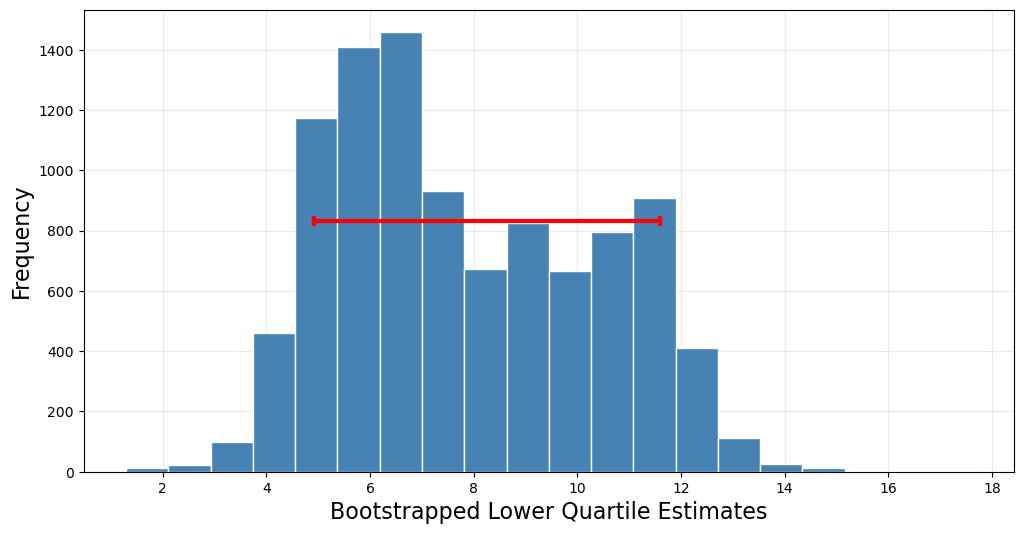

In [12]:
def bootstrapped_iqr(sample, num_boots=10000):
    
    list_of_iqrs = []
    
    for i in range(0,num_boots):
        resample = np.random.choice(sample, size = len(sample), replace = True)
        lq_resample = np.quantile(resample, 0.25)
        up_resample = np.quantile(resample, 0.75)
        iqr_resample = up_resample - lq_resample
        list_of_iqrs.append(iqr_resample)
    L = np.percentile(list_of_iqrs, 10)
    U = np.percentile(list_of_iqrs, 90)
    
    CI = [L, U]

    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
    pd.Series(list_of_iqrs).hist(ax=ax, color="steelblue", edgecolor="white", bins=20, density=False)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
    ax.set_xlabel("Bootstrapped Lower Quartile Estimates", fontsize=16)
    ax.set_ylabel("Frequency", fontsize=16)
    
    ax.plot([CI[0], CI[1]], [num_boots/12, num_boots/12], color="red", lw=3)
    ax.plot([CI[0], CI[0]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    ax.plot([CI[1], CI[1]], [num_boots/12-10, num_boots/12+10], color="red", lw=3)
    return CI


bootstrapped_iqr(dfHubble['x'])  

[Back to top](#top)

<a id='p3'></a>

## (24 pts) Problem 3: Practice with SLR and Inference


Is calcium in your drinking water good for your health? In England and Wales, an investigation of environmental causes of disease was conducted. The annual mortality rate (percentage of deaths) and the calcium concentration in the drinking water supply were recorded for $61$ large towns. The data in mortality.csv represent the annual mortality rate averaged over the years 1958–1964, and the calcium concentration in parts per million. 

The data has the following variables:

- `Rate`; the annual mortality rate (as a percentage) over the years 1958–1964 of 61 towns in England and Wales.
- `Calc`; the recorded calcium concentration in the drinking water supply for those towns, in parts-per-million


Load the data in Pandas and make a scatter plot with the calcium concentration as the feature on the horizontal axis and mortality rate as the response on the vertical axis. 


In [13]:
dfMort = pd.read_csv("mortality.csv")

**Part A1) (2 pts)** 
 - Create a linear regression model using the `OLS` method from `statsmodels`.   Note: Remember to include an intercept in your model (see NB 12 for how to do this).
 - Print the resulting `summary` table 
 - Typeset the actual line of best fit (as a print statement or in a markdown cell), using the coefficients from your fit.  (See: `.params`.)

In [14]:
mortality = sm.OLS(dfMort['Rate'], sm.add_constant(dfMort['Calc'])).fit()
print(mortality.summary())

print("Fitted Model: Y = {:.5f} + {:.5f}x".format(mortality.params[0], mortality.params[1]))

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     44.30
Date:                Tue, 25 Apr 2023   Prob (F-statistic):           1.03e-08
Time:                        05:16:48   Log-Likelihood:                 33.088
No. Observations:                  61   AIC:                            -62.18
Df Residuals:                      59   BIC:                            -57.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6764      0.029     57.217      0.0

**Part A2) (1 pt)**  What are the units of the slope and the intercept in your model from part b1?

**Solution**:
Since the units of the y-axis representing the mortality are in percetange of deaths per year and the x-axis representing the calcium in drinking water measured in parts-per-million(ppm), therefore the units of intercept are:

$\text{percentage of deaths per year}$

and the slope units are:

$\frac{\text{percentage of deaths per year}}{\text{calcium ppm}}$

Part A3) 

Several of the outputs are smaller than $0.001$ and thus show up in the table as $0.000$.  To see their exact values, you can use built-in attributes.  

Here are some useful built-in attributes to explore the output.  Note that in each output the first entry is info for the intercept and the 2nd entry is info for the slope.




In [15]:
print("Coefficients: ", mortality.params)
print("Standard errors: ", mortality.bse)
print("p-values: ", mortality.pvalues)
print("Confidence intervals", mortality.conf_int(.05))

Coefficients:  const    1.676356
Calc    -0.003226
dtype: float64
Standard errors:  const    0.029298
Calc     0.000485
dtype: float64
p-values:  const    2.165827e-53
Calc     1.033134e-08
dtype: float64
Confidence intervals               0         1
const  1.617730  1.734981
Calc  -0.004196 -0.002256



#### Part B: Visualize.

**Part B1 (4 pts)** Make the following 4 plots:


i).  A scatter plot of the data set with overlay the line of best least-squares fit.

ii).  A histogram of *residuals* of best least-squares fit.  

iii).  A Q-Q plot of *residuals*, comparing to a normal distribution.

iv).  A scatter plot where the original x-values are the x-axis and the *residuals* are the y-axis 

Text(0.5, 1.0, 'Data and Fit')

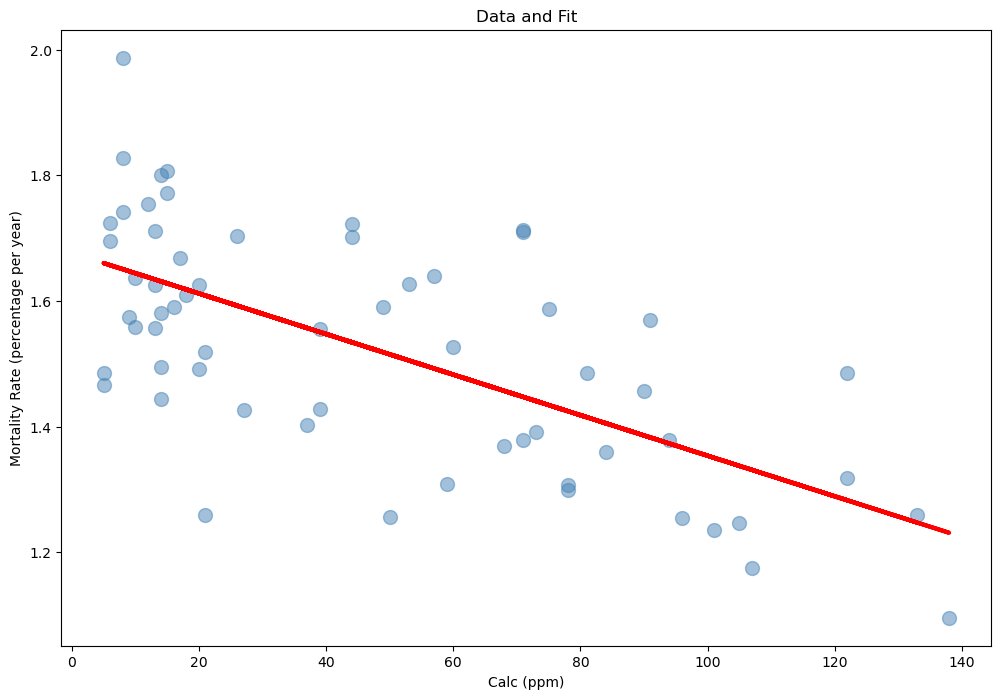

In [16]:
fig, ax= plt.subplots(figsize=(12,8))

ax.scatter(dfMort['Calc'], dfMort['Rate'],color="steelblue", alpha=0.5, s=100)
ax.plot( dfMort['Calc'], mortality.fittedvalues,color='red',lw=3)
ax.set_xlabel('Calc (ppm)')
ax.set_ylabel('Mortality Rate (percentage per year)')
ax.set_title('Data and Fit')

Text(0.5, 1.0, 'Histogram of Residuals')

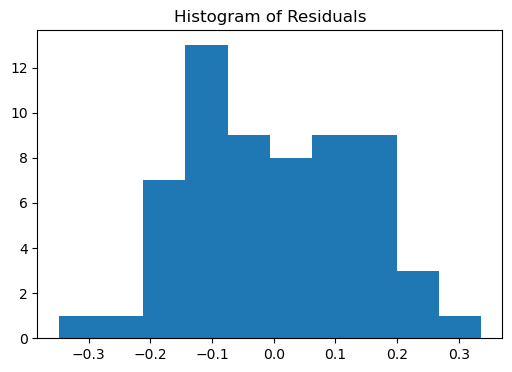

In [17]:
fig, ax= plt.subplots(figsize=(6,4))

ax.hist(mortality.resid)
ax.set_title('Histogram of Residuals')

Figure(640x480)


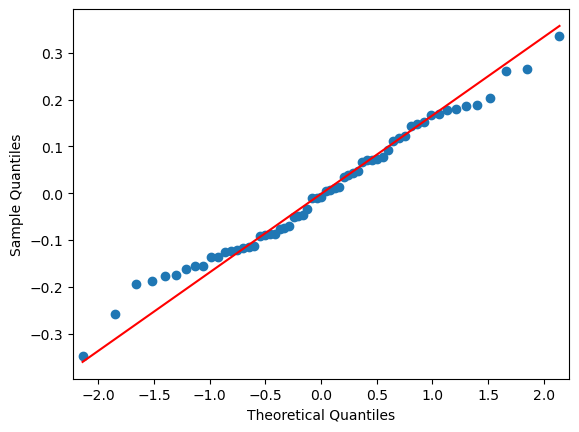

In [18]:
print(sm.qqplot(mortality.resid,line='q'))

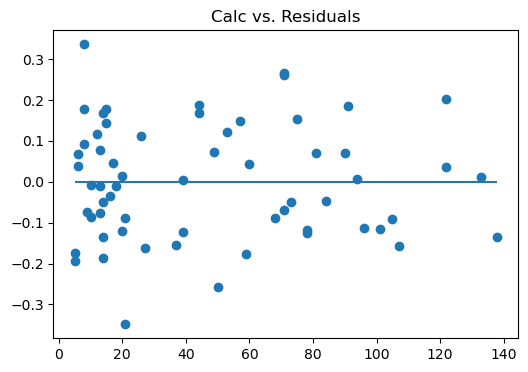

In [19]:
fig, ax= plt.subplots(figsize=(6,4))

ax.scatter(dfMort["Calc"], mortality.resid)
ax.set_title('Calc vs. Residuals')
ax.hlines(0, xmin=np.min(dfMort['Calc']), xmax=np.max(dfMort['Calc']))

**Part B2 (2 pts)**: What are the 4 major assumptions of the simple linear model?  For each of these assumptions, use your plots in part B1 to decide whether or not the data set meets those assumptions. Explain your reasoning.

**Solution:**
The first major assumption is the means make approximately a linear function, which based on the first graph with the data fit line, the means do appear to follow a downward linear trend.

The second major assumption is the data has independent errors or there is not a linear relationship in the errors that occur.  As seen by the last graph the best fit line for the errors has pratically no slope, therefore they are independent because they do not follow any noticeable linear relationship.

The third major assumption is the errors at each predictor are normally distributed. As seen by the histogram in the second graph, it does appear the errors in the data are normally distrbuted. Also the third graph of the qq-plot, shows how the data follows the normal best fit line closely, also indicating it is normally distributed.

The final major assumption is the variance in errors at each predictor are equal. As seen by the last graph the errors appear to be approximately the same distance from the line plotting the mean errors.

**Part C: Statistical Inference**: 

In the rest of this problem we will draw specific statistical conclusions from our analysis and linear model.  For each prompt, you should provide both a numerical answer and a full sentence explaining the conclusion.

**Part C1 (2 pts)**: 
Use the output of your model to find how much of the variance in the mortality rates can be explained by the calcium in the drinking water?  Does this seem like a high value or not given the context? Explain your reasoning.


In the first graph we see a linear relationship between mortality rates and the calcium in the drinking water, which shows as the calcium increases the death rate decreases. The correlation values will likely be high because the variation in errors is constant as seen by the last graph

**Part C2 (2 pts)**: Verify your answer to part C1 by calculating $R^2$ step-by step in Python.  i.e. complete the following code and output the $R^2$ value.  Verify that it matches the output from the model summary table.  



In [20]:
x = np.array(dfMort['Calc'])
y = np.array(dfMort['Rate'])
ybar = dfMort['Rate'].mean()

yhat = 0
SSE = 0
SSR = 0
SST = 0

for i in range(len(dfMort['Calc'])):
    yhat =  1.67636 + -0.00323 * x[i]
    SSE  = SSE + (y[i] - yhat)**2
    SSR  = SSR + (yhat - ybar)**2
    SST  = SST + (y[i] - ybar)**2

R2 = 1 - (SSE / SST)   

print("R2 =", R2)

R2 = 0.4288251546392102


**Part C3)**:  A skeptic insists that "there's no way water quality is actually affecting death rates."  You decide to test whether or not your linear model demonstrates otherwise.  

**C3i) (1 pt)**  To test this, you start with the null hypothesis that water quality is NOT actually affecting death rates.  Write the null hypothesis and the alternative hypothesis mathematically in terms of our model parameter(s):




$H_0: \beta = 0$

$H_A: \beta \neq 0$

**C3ii)(1 pt)**  Using the summary table output of the model, what is the $95\%$ confidence interval for the slope $\beta$?



In [21]:
print(mortality.summary())

                            OLS Regression Results                            
Dep. Variable:                   Rate   R-squared:                       0.429
Model:                            OLS   Adj. R-squared:                  0.419
Method:                 Least Squares   F-statistic:                     44.30
Date:                Tue, 25 Apr 2023   Prob (F-statistic):           1.03e-08
Time:                        05:16:49   Log-Likelihood:                 33.088
No. Observations:                  61   AIC:                            -62.18
Df Residuals:                      59   BIC:                            -57.96
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.6764      0.029     57.217      0.0

The 95% confidence interval based on summary print out is $[1.618, 1.735]$

**C3iii)(1 pts)** Using the confidence interval from C3ii, can you make a conclusion about your hypothesis test?  If so, what do you conclude?  If not, what additional information would you need?


Yes, it can be concluded since the confidence interval does not contain $0$ therefore we should reject the null hypothesis and accept the null.

**Part C4)**:  The government decides they believe your analysis in part C3 that Calcium levels are actually affecting death rates,  but augmenting the drinking supply with Calcium is costly.  They insist that they don't actually want to take any actions unless you can demonstrate that the effect size of `Calcium` concentration on mortality `Rate` is *large enough*.  

In particular, they will implement a calcification campaign if and only one part-per-million of `Calcium` decreases mortality rate by more than 0.0025 percentage at the $1\%$ significance level.
i.e. $\frac{\text{change in mortality %}}{\text{change in ppm of Calcium}}< -0.0025$

We can reframe this as a new hypothesis test, where

$H_0: \beta = -0.0025$

and

$H_A:  \beta < -0.0025$


**Part C4i (1 pt)**.  Since this is a one-sided test, our rejection region will only be in the left tail.  Find the cutoff for the rejection region  (i.e. find  $-t_{\alpha/2, n-2})$.  You can use built-in Python functions to calculate.



In [22]:
n = len(dfMort['Calc'])
t = stats.t.ppf(0.01, df = n - 2)

print("-t(alpha, n-2) =", t)

-t(alpha, n-2) = -2.3912288325162177


**Part C4ii (1 pt)**  The formula for the test statistic for this test assuming the null hypothesis is true is given by:

test_statistic $=\frac{b-\beta}{SE(b)}=\frac{b-(-.0025)}{SE(b)}$


Use the summary output from the model to find the terms needed to calculate this test statistic and then calculate.


In [23]:
#Using the standard error of 0.029 from the summary
test_stat = (-0.045941 + 0.0025) / 0.029

print("Test statistic is:", test_stat)

Test statistic is: -1.4979655172413793


**Part C4iii (1 pt)**  Is your test statistic in your rejection region or not?  What do you recommend to the government based on the results of this test?

Yes because $-1.49796$ is within the confidence interval which reaches out to $-2.39122$

**Part D** Prediction and Confidence Bands

**Part D1) (2 pts)**  Create one plot with the original data, the model, and the $95\%$ predication and confidence bands for the model (see nb12 for how to do this).


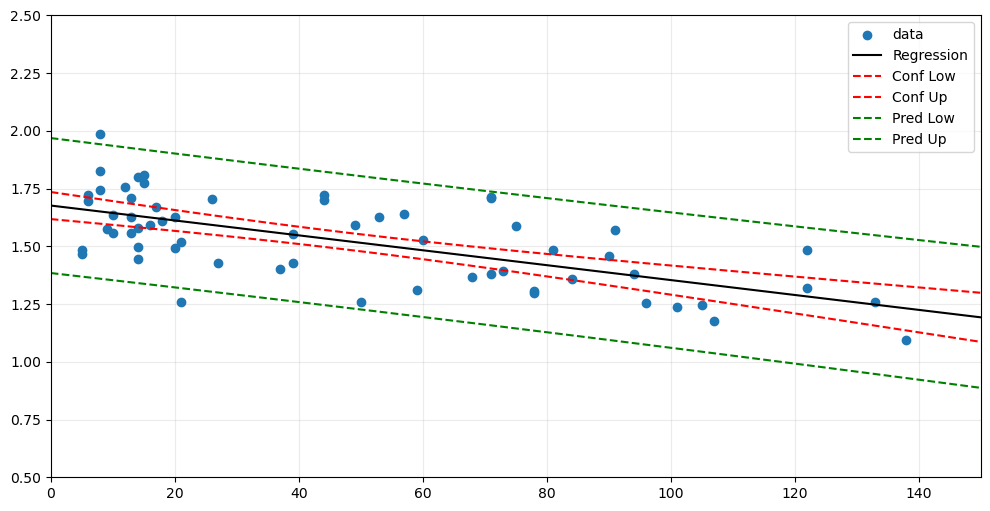

In [24]:
#Create Prediction and Confidence Bands

# Inspect the results
xgrd=np.linspace(0,150,1000) #grid for plotting
#find confidence and predictive intervals all over our plot:

predictions = mortality.get_prediction(sm.add_constant(xgrd))
predmat=predictions.summary_frame(alpha=0.05)


#plot it all
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12,6))
ax.grid(alpha=0.25)
ax.set_axisbelow(True)
ax.set_xlim([0,150])
ax.set_ylim([.5,2.5])
plt.scatter(dfMort['Calc'], dfMort['Rate'], label='data')

#Plot each column
plt.plot(xgrd,(predmat.mean_ci_lower+predmat.mean_ci_upper)/2, color='black', label='Regression')
plt.plot(xgrd,predmat.mean_ci_lower, 'r--', label='Conf Low')
plt.plot(xgrd,predmat.mean_ci_upper, 'r--', label='Conf Up')
plt.plot(xgrd,predmat.obs_ci_lower, 'g--', label='Pred Low')
plt.plot(xgrd,predmat.obs_ci_upper, 'g--', label='Pred Up')

plt.legend()
plt.show()


**Part D2) (1 pt)** Explain the difference between what the $95\%$ prediction band is measuring vs the $95\%$ confidence band.


The 95% prediction band tells us there is a 95% chance that at that point along the regression line we will find a data point in between the prediction bands, whereas the 95% confidence band tells us at that point along the the regression line there is a 95% chance the sample mean is within the upper and lower confidence bands.

**Part D3)**:  The town of Manchester and their football clubs are loathsome.  While the town wasn't originally tested, we are told that the calcium concentration in their drinking water is exactly 100 ppm.

**Part D3i (1 pt)** What is the 95% **prediction** interval for the mortality rate in Manchester?  In other words, given our linear model, what is the interval that we think should contain the actual mortality rate for Manchester?


**Part D3ii (1 pt)**  
What is the 95% **confidence** interval for the mortality rate in Manchester?  In other words, what is the interval that we think should contain the **mean** mortality rate for any town with a Calcium concentration of 100 ppm?


In [25]:
#Part D3i:
#Y = 1.67636 + -0.00323x where x = 100
manchester = 1.67636 - (0.00323 * 100) + .3
#prediction = mortality.get_prediction(sm.add_constant(np.array([1, 10])))
pre_upper = manchester + .2
pre_lower = manchester - .3
print("Manchester should be within the prediction interval: [", pre_lower,", ", pre_upper, "]")

#Part D3ii:
sm_x = dfMort['Rate'].mean()
n = len(dfMort['Rate'])
con_manchester = stats.t.interval(confidence=0.95, df=n-2, loc=sm_x, scale=stats.sem(dfMort['Rate']))
print("Manchester should be within the confidence interval:", con_manchester)

Manchester should be within the prediction interval: [ 1.3533600000000001 ,  1.8533600000000001 ]
Manchester should be within the confidence interval: (1.476066580116033, 1.5722285018511795)


**Answers To Selected Problems**

Problem 2
B1:  [9.5992725, 14.5098941]

B3ii:  Yes, we can reject the null and accept the alternative that $\mu_x\neq 16$

B3iii:  pvalue=$0.002953586$

C2:  Answers will vary.  Should be something close to [9.7, 14.3]

D1:  Answers will vary.  Should be something close to [4.6, 6.7]

D2:  Answers will vary.  Should be something close to [3.6, 11.2]

D3:  Answers will vary.  Should be something close to  [14.3, 17.8]

D4:  Answers will vary.  Should be something close to  [4.9, 11.6]

Problem 3

C4i:  -2.66175

C4ii:  test_statistic = -1.49795






## [Back to top](#top)
